# 04e — Basis Vectors and Matrix Columns

## Purpose

Understand a matrix as a transformation of the standard basis vectors.

The key idea is:
<p style="text-align: center; font-weight:700">
The columns of a matrix tell us where the basis vectors land.
</p>

Once we understand that, matrix-vector multiplication becomes less mysterious:

<p style="text-align: center;">
$\mathbf{v} = x\mathbf{e}_1 + y\mathbf{e}_2$
</p>

For a vector $\mathbf{v} = (x, y)$, the matrix does not treat the vector as an isolated arrow. It transforms the basis vectors, then rebuilds the vector using the same coefficients.

## Setup

We will use NumPy for the calculations and Matplotlib for the plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Plotting helpers

These helpers keep the examples focused on the maths rather than repeated plotting code.

In [2]:
def setup_axis(ax, title, limit=4):
    """Prepare a simple 2D coordinate axis."""
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_vector(ax, vector, label, start=(0, 0), linewidth=2, linestyle="-", alpha=1.0):
    """Draw a vector arrow from a starting point."""
    start = np.array(start, dtype=float)
    vector = np.array(vector, dtype=float)

    ax.arrow(
        start[0],
        start[1],
        vector[0],
        vector[1],
        head_width=0.12,
        head_length=0.18,
        length_includes_head=True,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=alpha,
    )

    end = start + vector
    ax.text(end[0] + 0.08, end[1] + 0.08, label, fontsize=11)


def draw_chain(ax, first, second, first_label, second_label, result_label):
    """Show vector addition by placing the second vector at the end of the first."""
    first = np.array(first, dtype=float)
    second = np.array(second, dtype=float)
    result = first + second

    draw_vector(ax, first, first_label, linewidth=2)
    draw_vector(ax, second, second_label, start=first, linewidth=2, linestyle="--")
    draw_vector(ax, result, result_label, linewidth=3)


def print_vector(name, vector):
    """Print a vector in a compact notebook-friendly format."""
    print(f"{name} = [{vector[0]: .2f}, {vector[1]: .2f}]")

## The standard basis vectors

In 2D, the standard basis vectors are the two ordinary one-step directions:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

$\mathbf{e}_1$ points one step along the x-axis.  
$\mathbf{e}_2$ points one step along the y-axis.

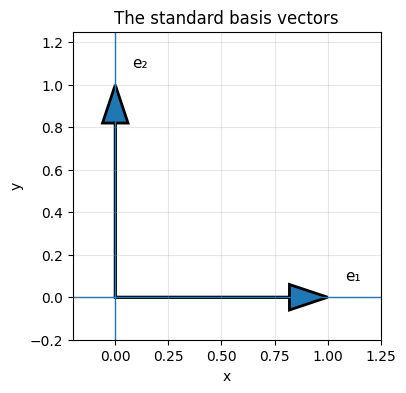

In [3]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])

fig, ax = plt.subplots(figsize=(4, 4))

setup_axis(
    ax,
    "The standard basis vectors",
    limit=1
)

# The action is entirely in the positive quadrant, so trim the unused space.
ax.set_xlim(-0.2, 1.25)
ax.set_ylim(-0.2, 1.25)

draw_vector(ax, e1, "e₁")
draw_vector(ax, e2, "e₂")

plt.show()

## A vector as a recipe using the basis vectors

Consider this vector:

$$
\mathbf{v} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

Its coordinates tell us how to build it from the standard basis vectors:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

So the vector is not just an arrow. It is also a set of instructions:

> take 2 steps in the $\mathbf{e}_1$ direction and 1 step in the $\mathbf{e}_2$ direction.

In [4]:
v = np.array([2, 1])

v_from_basis = 2 * e1 + 1 * e2

print_vector("v", v)
print_vector("2e1 + 1e2", v_from_basis)
print("Same result?", np.array_equal(v, v_from_basis))

v = [ 2.00,  1.00]
2e1 + 1e2 = [ 2.00,  1.00]
Same result? True


## A matrix transforms the basis vectors

Now define a matrix:

$$
A =
\begin{bmatrix}
1.5 & -0.8 \\
0.6 & 1.2
\end{bmatrix}
$$

The columns of this matrix tell us where the standard basis vectors land.

The first column is $A\mathbf{e}_1$:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
1.5 \\
0.6
\end{bmatrix}
$$

The second column is $A\mathbf{e}_2$:

$$
A\mathbf{e}_2 =
\begin{bmatrix}
-0.8 \\
1.2
\end{bmatrix}
$$

So this matrix sends:

$$
\mathbf{e}_1 \mapsto A\mathbf{e}_1
\qquad
\mathbf{e}_2 \mapsto A\mathbf{e}_2
$$

In [5]:
A = np.array([
    [1.5, -0.8],
    [0.6,  1.2],
])

Ae1 = A @ e1
Ae2 = A @ e2

print("A =")
print(A)
print()
print_vector("A @ e1", Ae1)
print_vector("A @ e2", Ae2)
print()
print_vector("first column of A", A[:, 0])
print_vector("second column of A", A[:, 1])

A =
[[ 1.5 -0.8]
 [ 0.6  1.2]]

A @ e1 = [ 1.50,  0.60]
A @ e2 = [-0.80,  1.20]

first column of A = [ 1.50,  0.60]
second column of A = [-0.80,  1.20]


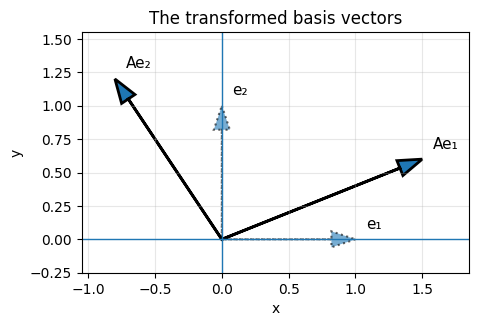

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))

setup_axis(
    ax,
    "The transformed basis vectors",
    limit=3
)

# This transformation mostly lives in a compact region around the origin.
ax.set_xlim(-1.05, 1.85)
ax.set_ylim(-0.25, 1.55)

# Original standard basis vectors, shown faintly for reference.
draw_vector(ax, e1, "e₁", linewidth=1.5, linestyle=":", alpha=0.6)
draw_vector(ax, e2, "e₂", linewidth=1.5, linestyle=":", alpha=0.6)

# Transformed basis vectors.
draw_vector(ax, Ae1, "Ae₁")
draw_vector(ax, Ae2, "Ae₂")

plt.show()

## Matrix-vector multiplication as rebuilding the vector

Our original vector was:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

After applying $A$, the coefficients do not change:

$$
A\mathbf{v} = 2(A\mathbf{e}_1) + 1(A\mathbf{e}_2)
$$

The matrix changes the basis vectors. The vector follows because it is built from those basis vectors.

In [7]:
Av = A @ v
Av_from_transformed_basis = 2 * Ae1 + 1 * Ae2

print_vector("A @ v", Av)
print_vector("2(A @ e1) + 1(A @ e2)", Av_from_transformed_basis)
print("Same result?", np.allclose(Av, Av_from_transformed_basis))

A @ v = [ 2.20,  2.40]
2(A @ e1) + 1(A @ e2) = [ 2.20,  2.40]
Same result? True


## Before and after

The next pair of plots shows the same vector recipe before and after the transformation.

Before:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

After:

$$
A\mathbf{v} = 2(A\mathbf{e}_1) + 1(A\mathbf{e}_2)
$$

The coefficients are the same. The basis vectors have moved.

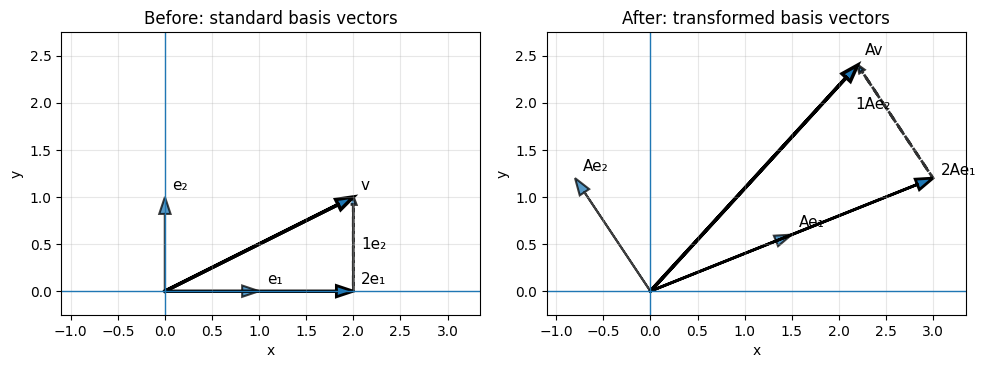

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# -------------------------
# Before: v = 2e₁ + 1e₂
# -------------------------
ax = axes[0]

setup_axis(
    ax,
    "Before: standard basis vectors",
    limit=3
)

# Compact limits: the construction sits almost entirely in the positive quadrant.
ax.set_xlim(-1.1, 3.35)
ax.set_ylim(-0.25, 2.75)

# Standard basis vectors.
draw_vector(ax, e1, "e₁", linewidth=1.5, alpha=0.75)
draw_vector(ax, e2, "e₂", linewidth=1.5, alpha=0.75)

# Build v = 2e₁ + 1e₂.
draw_vector(ax, 2 * e1, "2e₁", linewidth=2)

ax.arrow(
    2, 0,
    0, 1,
    length_includes_head=True,
    head_width=0.06,
    head_length=0.08,
    linewidth=2,
    linestyle="--",
    alpha=0.8
)

ax.text(
    2.08, 0.5,
    "1e₂",
    fontsize=11,
    ha="left",
    va="center"
)

draw_vector(ax, v, "v", linewidth=2.5)


# -------------------------
# After: Av = 2Ae₁ + 1Ae₂
# -------------------------
ax = axes[1]

setup_axis(
    ax,
    "After: transformed basis vectors",
    limit=3
)

# Compact limits: enough room for all transformed vectors and labels,
# without the large unused negative quadrant.
ax.set_xlim(-1.1, 3.35)
ax.set_ylim(-0.25, 2.75)

# Transformed basis vectors.
draw_vector(ax, Ae1, "Ae₁", linewidth=1.5, alpha=0.75)
draw_vector(ax, Ae2, "Ae₂", linewidth=1.5, alpha=0.75)

# Build Av = 2Ae₁ + 1Ae₂.
# Draw 2Ae₁ without the helper label so we can place the label manually.
ax.arrow(
    0, 0,
    (2 * Ae1)[0], (2 * Ae1)[1],
    length_includes_head=True,
    head_width=0.12,
    head_length=0.18,
    linewidth=2
)

ax.text(
    3.08, 1.28,
    "2Ae₁",
    fontsize=11,
    ha="left",
    va="center"
)

# Add 1Ae₂ from the end of 2Ae₁.
ax.arrow(
    (2 * Ae1)[0], (2 * Ae1)[1],
    Ae2[0], Ae2[1],
    length_includes_head=True,
    head_width=0.06,
    head_length=0.08,
    linewidth=2,
    linestyle="--",
    alpha=0.8
)

ax.text(
    2.18, 1.98,
    "1Ae₂",
    fontsize=11,
    ha="left",
    va="center"
)

# Final transformed vector, drawn manually so the label can be nudged neatly.
ax.arrow(
    0, 0,
    Av[0], Av[1],
    length_includes_head=True,
    head_width=0.12,
    head_length=0.18,
    linewidth=2.5
)

ax.text(
    2.28, 2.48,
    "Av",
    fontsize=11,
    ha="left",
    va="bottom"
)

plt.tight_layout()
plt.show()

## Reading the matrix by columns

Because the columns show where the basis vectors land, we can read this matrix geometrically:

$$
A = \begin{bmatrix}
1.5 & -0.8 \\
0.6 & 1.2
\end{bmatrix}
$$

The first column says:

$$
\mathbf{e}_1 \mapsto \begin{bmatrix}1.5 \\ 0.6\end{bmatrix}
$$

The second column says:

$$
\mathbf{e}_2 \mapsto \begin{bmatrix}-0.8 \\ 1.2\end{bmatrix}
$$

So multiplying by $A$ means rebuilding every vector using those new basis directions.

In [9]:
columns = [A[:, 0], A[:, 1]]

for index, column in enumerate(columns, start=1):
    print_vector(f"Column {index}", column)

Column 1 = [ 1.50,  0.60]
Column 2 = [-0.80,  1.20]


## A second vector

To check that this is not a special trick for $[2, 1]$, try another vector:

$$
\mathbf{w} = \begin{bmatrix}-1 \\ 2\end{bmatrix}
$$

That means:

$$
\mathbf{w} = -1\mathbf{e}_1 + 2\mathbf{e}_2
$$

After the transformation:

$$
A\mathbf{w} = -1(A\mathbf{e}_1) + 2(A\mathbf{e}_2)
$$

In [10]:
w = np.array([-1, 2])

Aw = A @ w
Aw_from_transformed_basis = -1 * Ae1 + 2 * Ae2

print_vector("A @ w", Aw)
print_vector("-1(A @ e1) + 2(A @ e2)", Aw_from_transformed_basis)
print("Same result?", np.allclose(Aw, Aw_from_transformed_basis))

A @ w = [-3.10,  1.80]
-1(A @ e1) + 2(A @ e2) = [-3.10,  1.80]
Same result? True


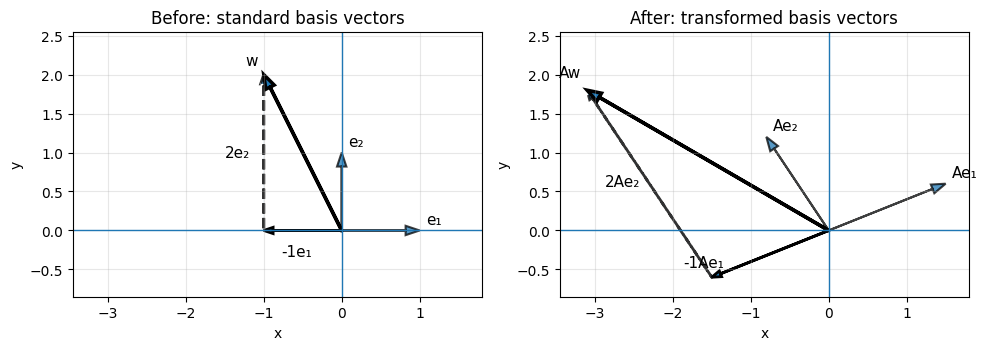

In [16]:
# Make sure these are available even if this cell is rerun independently.
w = np.array([-1, 2])
Aw = A @ w

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Shared limits for visual comparison.
# The transformed version reaches further left, so both plots use the same view.
shared_xlim = (-3.45, 1.8)
shared_ylim = (-0.85, 2.55)


# -------------------------
# Before: w = -1e₁ + 2e₂
# -------------------------
ax = axes[0]

setup_axis(
    ax,
    "Before: standard basis vectors",
    limit=4
)

ax.set_xlim(*shared_xlim)
ax.set_ylim(*shared_ylim)

# Standard basis vectors.
draw_vector(ax, e1, "e₁", linewidth=1.5, alpha=0.75)
draw_vector(ax, e2, "e₂", linewidth=1.5, alpha=0.75)

# Build w = -1e₁ + 2e₂.
ax.arrow(
    0, 0,
    -1, 0,
    length_includes_head=True,
    head_width=0.08,
    head_length=0.12,
    linewidth=2
)

ax.text(
    -0.58, -0.18,
    "-1e₁",
    fontsize=11,
    ha="center",
    va="top"
)

ax.arrow(
    -1, 0,
    0, 2,
    length_includes_head=True,
    head_width=0.08,
    head_length=0.12,
    linewidth=2,
    linestyle="--",
    alpha=0.8
)

ax.text(
    -1.18, 1.0,
    "2e₂",
    fontsize=11,
    ha="right",
    va="center"
)

# Final vector w.
ax.arrow(
    0, 0,
    w[0], w[1],
    length_includes_head=True,
    head_width=0.12,
    head_length=0.18,
    linewidth=2.5
)

ax.text(
    -1.08, 2.08,
    "w",
    fontsize=11,
    ha="right",
    va="bottom"
)


# -------------------------
# After: Aw = -1Ae₁ + 2Ae₂
# -------------------------
ax = axes[1]

setup_axis(
    ax,
    "After: transformed basis vectors",
    limit=4
)

ax.set_xlim(*shared_xlim)
ax.set_ylim(*shared_ylim)

# Transformed basis vectors.
draw_vector(ax, Ae1, "Ae₁", linewidth=1.5, alpha=0.75)
draw_vector(ax, Ae2, "Ae₂", linewidth=1.5, alpha=0.75)

# Build Aw = -1Ae₁ + 2Ae₂.
minus_Ae1 = -1 * Ae1
two_Ae2 = 2 * Ae2

ax.arrow(
    0, 0,
    minus_Ae1[0], minus_Ae1[1],
    length_includes_head=True,
    head_width=0.08,
    head_length=0.12,
    linewidth=2
)

ax.text(
    -1.34, -0.42,
    "-1Ae₁",
    fontsize=11,
    ha="right",
    va="center"
)

ax.arrow(
    minus_Ae1[0], minus_Ae1[1],
    two_Ae2[0], two_Ae2[1],
    length_includes_head=True,
    head_width=0.08,
    head_length=0.12,
    linewidth=2,
    linestyle="--",
    alpha=0.8
)

ax.text(
    -2.42, 0.62,
    "2Ae₂",
    fontsize=11,
    ha="right",
    va="center"
)

# Final transformed vector Aw.
ax.arrow(
    0, 0,
    Aw[0], Aw[1],
    length_includes_head=True,
    head_width=0.12,
    head_length=0.18,
    linewidth=2.5
)

ax.text(
    -3.18, 1.92,
    "Aw",
    fontsize=11,
    ha="right",
    va="bottom"
)

plt.tight_layout()
plt.show()

## Why this matters for machine learning

Matrices appear everywhere in machine learning.

They can represent:

- transformations of data
- feature projections
- linear layers in neural networks
- changes of coordinate systems
- collections of learned weights

The important habit is to stop seeing matrix multiplication as only a mechanical calculation.

A matrix can also be read as a transformation:

> it moves the basis vectors, then every other vector follows from that movement.

## Summary

The standard basis vectors are:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

A vector with coordinates $x$ and $y$ can be read as:

$$
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
x\mathbf{e}_1 + y\mathbf{e}_2
$$

For a matrix $A$:

- the first column is where $\mathbf{e}_1$ lands
- the second column is where $\mathbf{e}_2$ lands
- matrix-vector multiplication rebuilds the vector using the transformed basis vectors
- the coefficients stay the same; the basis vectors change

The central idea is:

$$
A
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
x(A\mathbf{e}_1) + y(A\mathbf{e}_2)
$$

So a matrix is not just a grid of numbers. In this notebook, we can read it as a transformation that moves the basis vectors, then rebuilds every other vector from those transformed basis vectors.